#### Executive summary
This project presents a deep learning approach to classifying images using the CIFAR-10 dataset. The primary challenge of overfitting was addressed through batch normalization, data augmentation, and, as an extension beyond the project scope,Dropout.

* **Handling overfitting**: The CIFAR-10 dataset consists of 60,000 images from 
  10 classes with equal distribution. To handle overfitting, we generate plausible 
  variations of training samples by expanding the dataset through augmentation.
* **Neural network architecture**: We implemented different CNN architectures using 
  tanh and ReLU activations, BatchNormalization, Data Augmentation, and grayscale 
  conversion.
* **Conclusion**: BatchNormalization stabilized training but did not address 
  overfitting on its own. Data augmentation mitigated overfitting, keeping the gap 
  between training and validation loss narrow, with accuracy at 70%. Combining 
  augmentation, BatchNormalization, and Dropout pushed accuracy to approximately 81%.


In [3]:
import os
import random
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import seaborn as sns

In [4]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

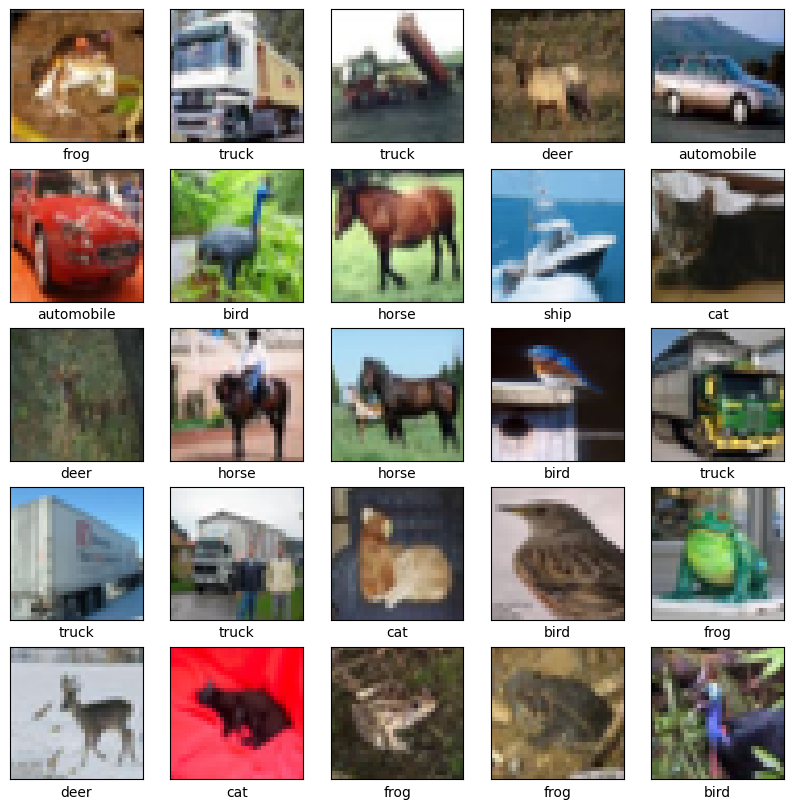

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize = (10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [6]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = 'relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = 'relu'))

/Users/ash/Documents/Dokument – Ashkans MacBook Air/MT7042 - Deep Learning/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Let's display the architecture of your model so far:

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dense(10))

Here's the complete architecture of your model:

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

The network summary shows that (4, 4, 64) outputs were flattened into vectors of shape (1024) before going through two Dense layers.

### Compile and train the model

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs = 10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3631 - loss: 1.7192 - val_accuracy: 0.5866 - val_loss: 1.1622
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5921 - loss: 1.1443 - val_accuracy: 0.6535 - val_loss: 0.9976
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6552 - loss: 0.9705 - val_accuracy: 0.6797 - val_loss: 0.9346
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6934 - loss: 0.8704 - val_accuracy: 0.6911 - val_loss: 0.9220
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7193 - loss: 0.8019 - val_accuracy: 0.6985 - val_loss: 0.8886
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7384 - loss: 0.7454 - val_accuracy: 0.6982 - val_loss: 0.8934
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7549 - loss: 0.6998 - val_accuracy: 0.7020 - val_loss: 0.9076
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7727 - loss: 0.6498 - 

### Evaluate the model

313/313 - 1s - 2ms/step - accuracy: 0.6793 - loss: 1.0555


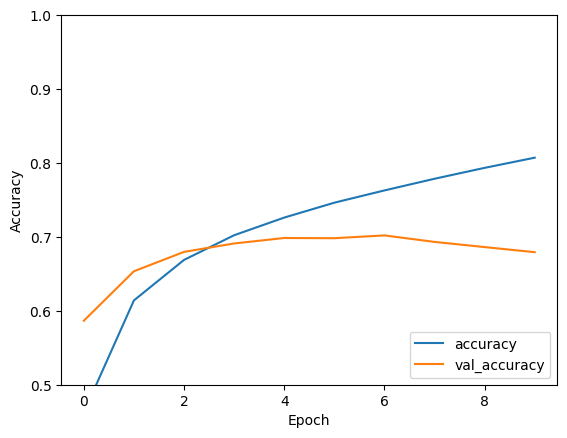

In [11]:
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose = 2)

In [12]:
print(test_acc)

0.6793000102043152


This simple CNN has achieved a test accuracy of around 68%. 

#### Task 2
##### Repeat task 1 using tanh as activation

In [13]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation = 'tanh', input_shape = (32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = 'tanh'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = 'tanh'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation = 'tanh'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer = 'adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, 
                    epochs = 10, 
                    validation_data = (test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4176 - loss: 1.6264 - val_accuracy: 0.5916 - val_loss: 1.1719
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5891 - loss: 1.1665 - val_accuracy: 0.6245 - val_loss: 1.0758
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6345 - loss: 1.0458 - val_accuracy: 0.6303 - val_loss: 1.0700
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6639 - loss: 0.9708 - val_accuracy: 0.6303 - val_loss: 1.0677
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6838 - loss: 0.9128 - val_accuracy: 0.6453 - val_loss: 1.0314
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7008 - loss: 0.8655 - val_accuracy: 0.6354 - val_loss: 1.0838
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7141 - loss: 0.8279 - val_accuracy: 0.6401 - val_loss: 1.0786
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7297 - loss: 0.7866 - 

313/313 - 1s - 2ms/step - accuracy: 0.6354 - loss: 1.1167
0.6353999972343445


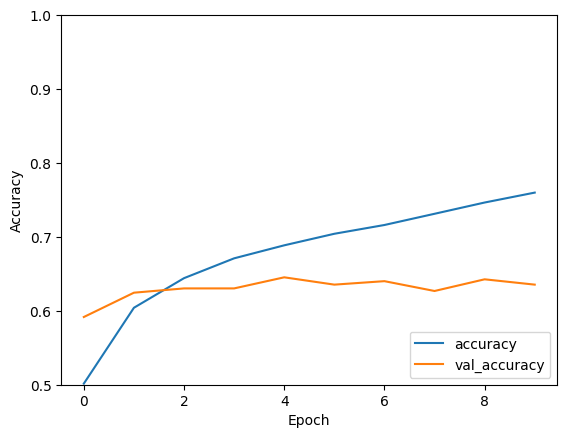

In [16]:
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc = 'lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose = 2)

print(test_acc)

#### Task 2
We obtain an accuracy of approximately 63% and notice that it is lower than when using ReLU. 

The computation of the ReLU activation function is simpler. "The ReLU activation function makes model training easier when using different parameter initialization methods" ([Dive into Deep Learning (2023)](#ref-d2l)).The main reason we usually do not use tanh in CNNs is that it suffers from the 'vanishing gradient problem', its gradient approaches zero when inputs are large, halting learning. Additionally, the function is 'computationally expensive' because it requires calculating an exponential term, as seen in the formula $tanh(z) = \frac{2}{1+e^{-2z}}-1$. 

#### Task 3 
The CIFAR-10 data set consists of 60,000 colour pictures with 32x32 pixels. The small image size (32x32) allows for quick training and experimentation with convolutional netural networks. We start with few filters (32) to capture simple features (lines), and increase to more filters (64) deeper in the network to capture complex combinations (shapes/objects) as the spatial dimension shrinks.

#### Task 4 – Extend the code (ReLU) by incorporating batch normalization. 
We start by decoupling activation and Conv2D so batch normalization (BN) can be sandwiched between them. According to [Deep learning with Python](#ref-chollet), the output of Conv2D layer gets normalized, the layer does not need its own bias vector, why we pass 'use_bias = False' as an argument.

In [17]:
model = models.Sequential()

# Decoupling activation and Conv2D so BN can be sandwiched between them 
# Because the output of the Conv2D layer gets normalized, the layer
# doesn't need its own bias vector.
model.add(layers.Conv2D(32, (3, 3), use_bias = False, input_shape = (32, 32, 3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), use_bias = False))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), use_bias = False))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, use_bias = False))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dense(10))

In [18]:
import keras

model.compile(
    optimizer = keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs = 30, 
                    validation_data=(test_images, test_labels))


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4661 - loss: 1.4904 - val_accuracy: 0.5468 - val_loss: 1.3177
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6663 - loss: 0.9467 - val_accuracy: 0.6089 - val_loss: 1.1472
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7252 - loss: 0.7916 - val_accuracy: 0.5596 - val_loss: 1.3099
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7651 - loss: 0.6833 - val_accuracy: 0.5456 - val_loss: 1.4545
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7949 - loss: 0.5918 - val_accuracy: 0.5616 - val_loss: 1.4482
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8281 - loss: 0.5101 - val_accuracy: 0.5594 - val_loss: 1.5665
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8506 - loss: 0.4427 - val_accuracy: 0.5914 - val_loss: 1.5015
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8711 - loss:

Text(0, 0.5, 'Loss')

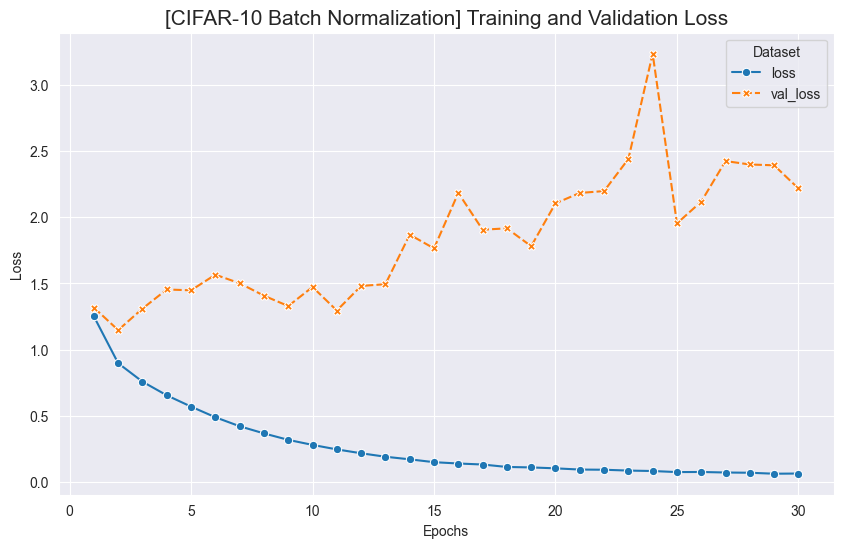

In [19]:
df_history = pd.DataFrame(history.history) # Create a DataFrame from history
df_history['epoch'] = range(1, len(df_history) + 1)

# Melt plot to fit seaborns long-format
df_plot = df_history.melt(id_vars = 'epoch', 
                          value_vars = ['loss', 'val_loss'], 
                          var_name = 'Dataset', 
                          value_name = 'Loss')

plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
sns.lineplot(data = df_plot, 
             x = 'epoch', 
             y = 'Loss', 
             hue = 'Dataset', 
             style = 'Dataset', 
             markers = True)
plt.title("[CIFAR-10 Batch Normalization] Training and Validation Loss", 
          fontsize = 15)
plt.xlabel("Epochs")
plt.ylabel("Loss")

313/313 - 1s - 2ms/step - accuracy: 0.6917 - loss: 2.2184


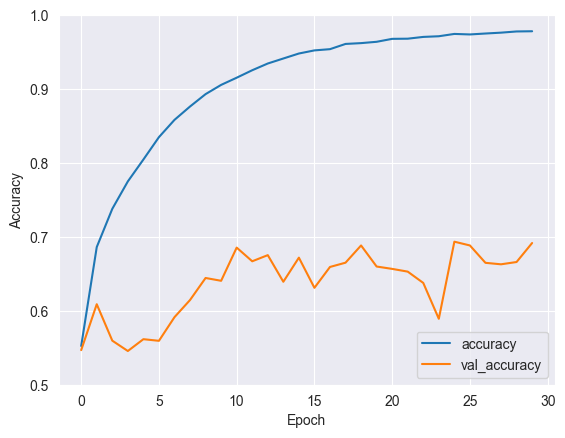

In [20]:
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc = 'lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose = 2)

We observe the model's accuracy improve to 69%, with the training loss decreasing smoothly and steadily. This confirms that batch normalization has successfully stabilized the network's optimization. However, the learning curve reveals clear signs of overfitting: the validation loss fails to converge, bouncing around 0.75 and trending upward. While the model performs well on the training data, it struggles to generalize to unseen examples. To address this high variance, [Dive into Deep Learning (2023)](#ref-d2l) suggests introducing regularization techniques such as data augmentation or dropout.

According to [Chollet (2025)](#ref-chollet), batch normalization "can adaptively normalize data even as the mean and variance change over time during training." The main mechanism is that during training it uses the mean and variance of each batch to normalize samples — much like standard z-score standardization. Crucially, it simultaneously tracks an exponential moving average of these statistics to enable inference once training is complete.

Regarding *why* it works, Chollet and notes there are various hypotheses but "no certitudes." This uncertainty is echoed in [Dive into Deep Learning (2023)](#ref-d2l), which similarly acknowledges the lack of a definitive theoretical explanation. While Ioffe and Szegedy (2015) originally proposed that it operates by "reducing internal covariate shift," this has since been contested. Santurkar et al. (2018) argue that the primary benefit is a smoothing effect on the optimization landscape, which makes gradients more predictive and allows for faster convergence and less sensitivity to hyperparameter choices.

Finally, Chollet notes that placing normalization *before* the activation function maximizes the utilization of ReLU, which motivates our architecture above.

#### Task 5 Apply Data Augmentation

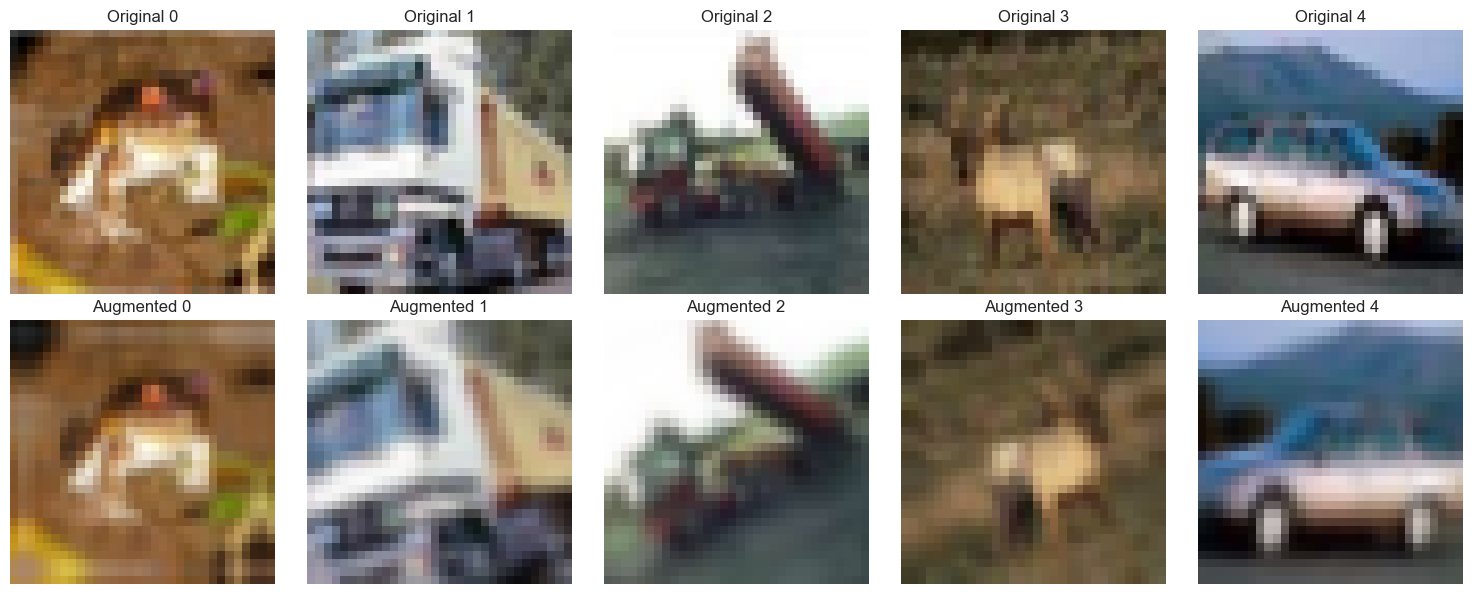

In [21]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1), 
    tf.keras.layers.RandomZoom(0.2),
])

plt.figure(figsize=(15, 6))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    original = train_images[i]
    plt.imshow(train_images[i])

    plt.title(f"Original {i}")
    plt.axis("off")

    #Augmented images
    plt.subplot(2, 5, i + 6)
    image_batch = tf.expand_dims(original, 0)
    augmented = data_augmentation(image_batch, training = True)

    plt.imshow(augmented[0])
    plt.title(f"Augmented {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [34]:
model = models.Sequential()

model.add(layers.Input(shape=(32, 32, 3)))
model.add(data_augmentation)

model.add(layers.Conv2D(32, (3, 3), use_bias = False))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), use_bias = False))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), use_bias = False))
model.add(layers.Activation('relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, use_bias = False))
model.add(layers.Activation('relu'))
model.add(layers.Dense(10))

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics=['accuracy'])

In [35]:
history = model.fit(train_images, train_labels, epochs = 50, 
                    validation_data=(test_images, test_labels))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3143 - loss: 1.8451 - val_accuracy: 0.5095 - val_loss: 1.3524
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4957 - loss: 1.3981 - val_accuracy: 0.5589 - val_loss: 1.2505
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5473 - loss: 1.2671 - val_accuracy: 0.6019 - val_loss: 1.1246
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5769 - loss: 1.1948 - val_accuracy: 0.6078 - val_loss: 1.1499
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5947 - loss: 1.1433 - val_accuracy: 0.6274 - val_loss: 1.0851
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6157 - loss: 1.0972 - val_accuracy: 0.6474 - val_loss: 1.0239
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6274 - loss: 1.0659 - val_accuracy: 0.6349 - val_loss: 1.0768
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6391 - loss: 1

Text(0, 0.5, 'Loss')

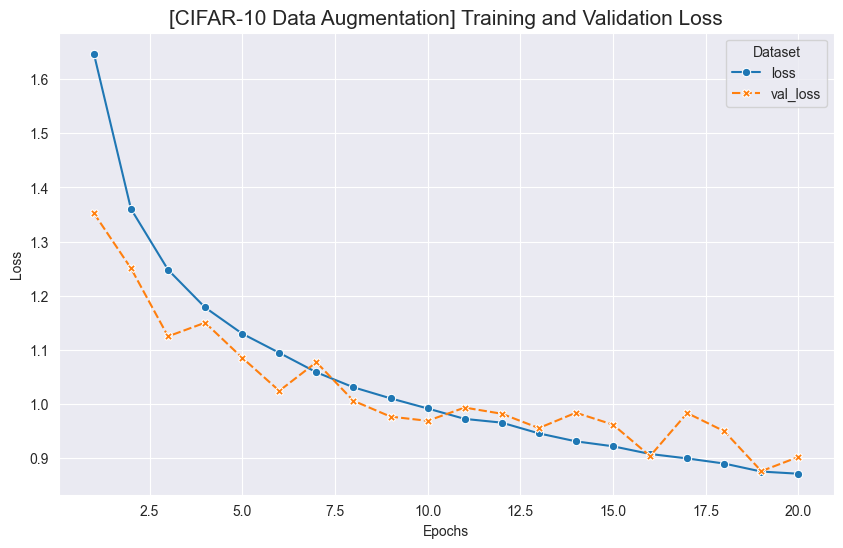

In [39]:
df_history = pd.DataFrame(history.history) # Create a DataFrame from history
df_history['epoch'] = range(1, len(df_history) + 1)

# Melt plot to fit seaborns long-format
df_plot = df_history.melt(id_vars = 'epoch', 
                          value_vars = ['loss', 'val_loss'], 
                          var_name = 'Dataset', 
                          value_name = 'Loss')

plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
sns.lineplot(data = df_plot, x = 'epoch', y = 'Loss', hue = 'Dataset', 
             style = 'Dataset', markers = True)
plt.title("[CIFAR-10 Data Augmentation] Training and Validation Loss", 
          fontsize = 15)
plt.xlabel("Epochs")
plt.ylabel("Loss")

313/313 - 1s - 2ms/step - accuracy: 0.7022 - loss: 0.9016


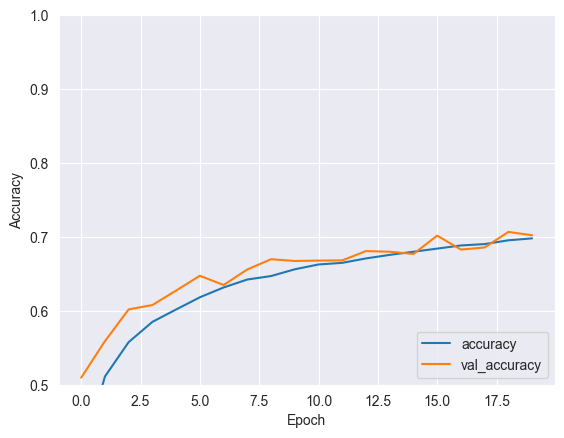

In [40]:
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose = 2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


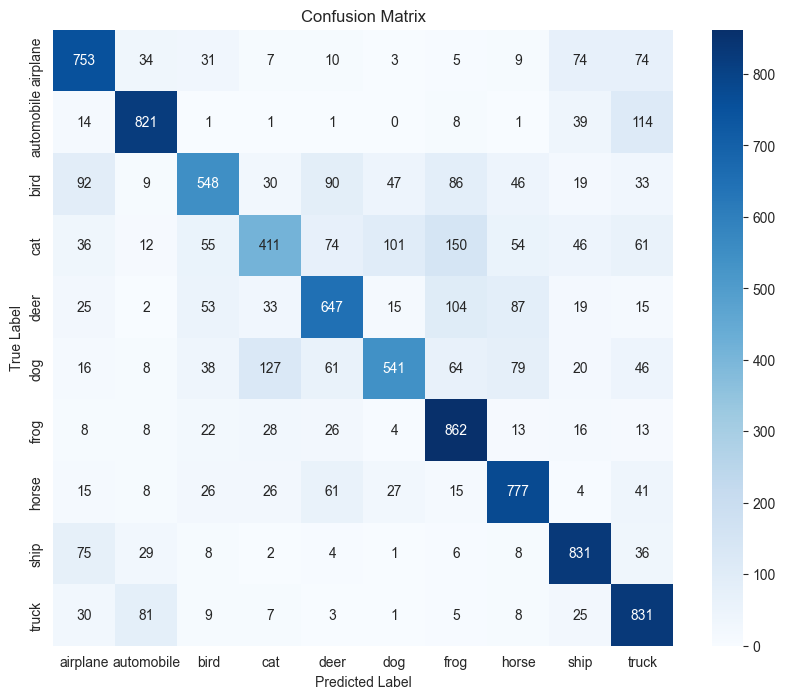

In [38]:
from sklearn.metrics import confusion_matrix

predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis = 1)

# CIFAR-10 labels are often 2D arrays
# We flatten them to 1D to match our predictions
true_classes = test_labels.flatten()

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a heatmap
sns.heatmap(cm, annot = True, 
            fmt = 'd', 
            cmap = 'Blues', 
            xticklabels = class_names, yticklabels = class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

We observe an accuracy of approximately 70% using data augmentation with the same architecture as our Task 1 benchmark. While the training loss decreases smoothly, the validation loss exhibits some volatility. Both curves converge closely by epoch 20, suggesting that data augmentation has been effective at improving generalization. the model shows no clear signs of overfitting, as the gap between training and validation loss remains narrow throughout training. 

By augmenting the training data we generate plausible variations of training samples, effectively expanding the dataset. The goal, according to [Chollet (2025)](ref-#chollet), "is that at training time, your model will never see the exact same picture twice". By exposing the model to transformations such as rotation, flip, or zoom, it learns to generalize better rather than memorizing specific pixels.

To further regularize the network and stabilize convergence, [Chollet (2025)](#ref-chollet) proposes implementing Dropout. Although not required for this assignment, we will explore this in the final stage of the project.

Further analysis of the confusion matrix reveals that the model generalizes well on visually distinct classes with unique structural features (e.g., Ship or Automobile). Performance degrades on classes sharing high visual resemblance, such as Cat, Dog, and Deer, where the model struggles to discern the fine-grained features required to distinguish these animals, leading to frequent misclassifications among them.

#### Task 6 - Grayscale


In [27]:
train_gray = tf.image.rgb_to_grayscale(train_images)
test_gray = tf.image.rgb_to_grayscale(test_images)

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (32, 32, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = 'relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = 'relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dense(10))

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics=['accuracy'])

history = model.fit(train_gray, train_labels, epochs = 20, 
                    validation_data=(test_gray, test_labels))


Epoch 1/20


/Users/ash/Documents/Dokument – Ashkans MacBook Air/MT7042 - Deep Learning/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2966 - loss: 1.9037 - val_accuracy: 0.5141 - val_loss: 1.3731
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5214 - loss: 1.3501 - val_accuracy: 0.5782 - val_loss: 1.1963
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5924 - loss: 1.1573 - val_accuracy: 0.6103 - val_loss: 1.1156
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6334 - loss: 1.0457 - val_accuracy: 0.6354 - val_loss: 1.0605
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6625 - loss: 0.9657 - val_accuracy: 0.6437 - val_loss: 1.0403
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6873 - loss: 0.9079 - val_accuracy: 0.6358 - val_loss: 1.0858
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7009 - loss: 0.8634 - val_accuracy: 0.6325 - val_loss: 1.1049
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7147 - loss: 0.8220 - val_accurac

Text(0, 0.5, 'Loss')

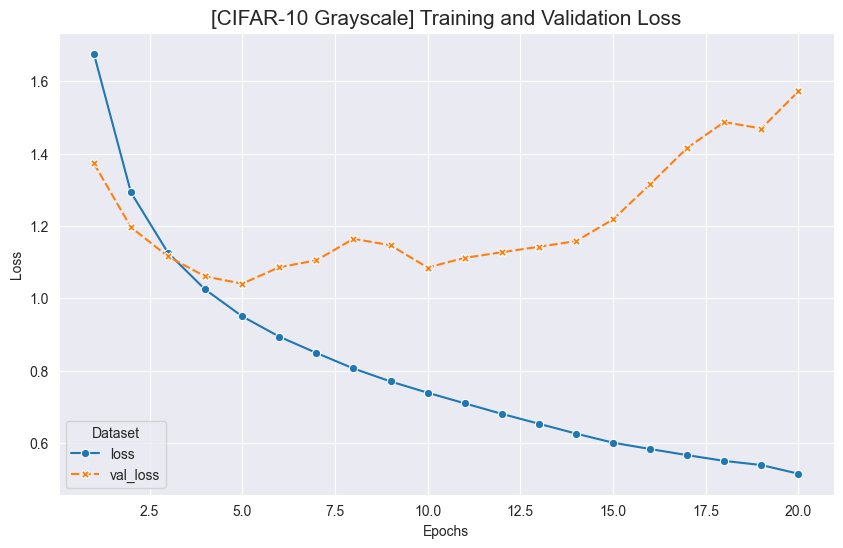

In [28]:
df_history = pd.DataFrame(history.history) # Create a DataFrame from history
df_history['epoch'] = range(1, len(df_history) + 1)

# Melt plot to fit seaborns long-format
df_plot = df_history.melt(id_vars = 'epoch', 
                          value_vars = ['loss', 'val_loss'], 
                          var_name = 'Dataset', 
                          value_name = 'Loss')

plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
sns.lineplot(data = df_plot, x = 'epoch', y = 'Loss', hue = 'Dataset', 
             style = 'Dataset', markers = True)
plt.title("[CIFAR-10 Grayscale] Training and Validation Loss", 
          fontsize = 15)
plt.xlabel("Epochs")
plt.ylabel("Loss")

313/313 - 0s - 1ms/step - accuracy: 0.5984 - loss: 1.5722


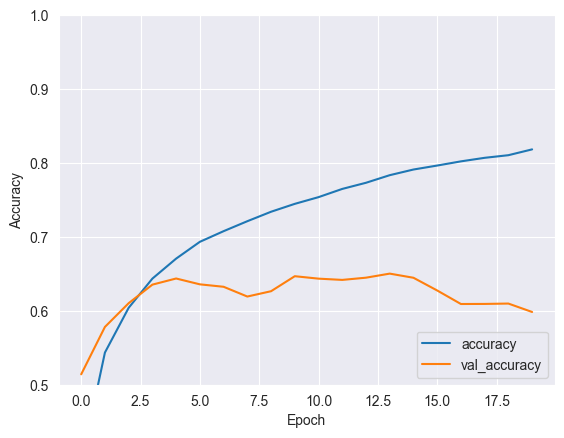

In [29]:
plt.plot(history.history['accuracy'], label = 'accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_gray,  test_labels, verbose = 2)

As anticipated, overfitting manifests early, appearing within the first 15 epochs in the absence of batch normalization or data augmentation. Furthermore, the overall accuracy is lower (60%) compared to the baseline RGB architecture from Task 1. This performance drop is expected, as the model is forced to rely exclusively on structural features (edges, textures, and shapes). We hypothesize that color is a strong feature in CIFAR-10 as certain classes exhibit strong color correlations (e.g., frogs are typically green, deer are brown), which the grayscale model cannot utilize.

#### Appendix: Task 5 - Further Investigation

In [30]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Build model
model = models.Sequential()
model.add(layers.Input(shape=(32, 32, 3)))

# Augmentation
model.add(data_augmentation)

# Block 1
model.add(layers.Conv2D(32, (3, 3), padding = 'same', use_bias = False)) # Added padding
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2
model.add(layers.Conv2D(64, (3, 3), padding= 'same', use_bias = False)) # Added padding
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2)) # Added dropout

# Block 3
model.add(layers.Conv2D(64, (3, 3), padding = 'same', use_bias = False)) # Added padding
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.3)) # Increased droput

# Classification Head
model.add(layers.Flatten())
model.add(layers.Dense(64, use_bias = False))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10))

model.compile(
    optimizer = keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs = 300, 
                    validation_data=(test_images, test_labels))

Epoch 1/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.3711 - loss: 1.7587 - val_accuracy: 0.3921 - val_loss: 1.7582
Epoch 2/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5188 - loss: 1.3444 - val_accuracy: 0.5408 - val_loss: 1.2612
Epoch 3/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5611 - loss: 1.2366 - val_accuracy: 0.5720 - val_loss: 1.1955
Epoch 4/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.5873 - loss: 1.1691 - val_accuracy: 0.5970 - val_loss: 1.1519
Epoch 5/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6040 - loss: 1.1204 - val_accuracy: 0.5567 - val_loss: 1.2701
Epoch 6/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6193 - loss: 1.0808 - val_accuracy: 0.6496 - val_loss: 0.9881
Epoch 7/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6299 - loss: 1.0531 - val_accuracy: 0.6204 - val_loss: 1.0736
Epoch 8/200
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 

Text(0, 0.5, 'Loss')

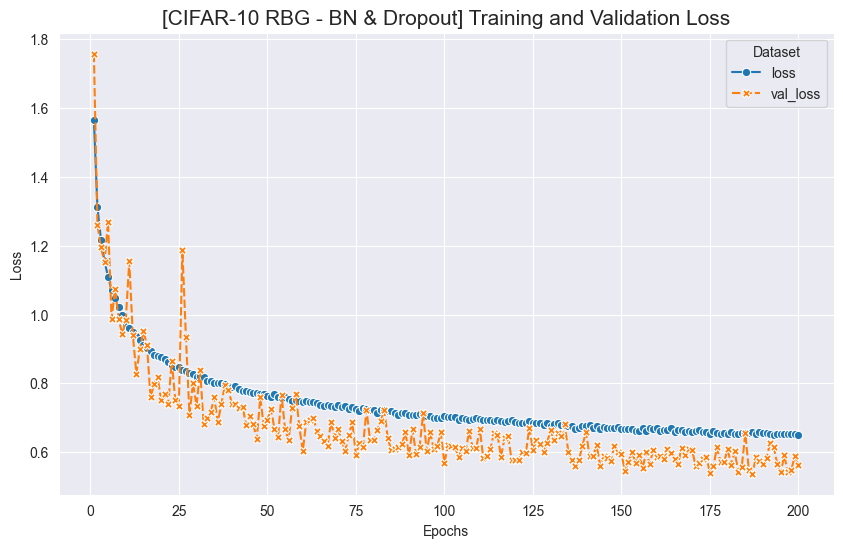

In [31]:
df_history = pd.DataFrame(history.history) # Create a DataFrame from history
df_history['epoch'] = range(1, len(df_history) + 1)

# Melt plot to fit seaborns long-format
df_plot = df_history.melt(id_vars = 'epoch', 
                          value_vars = ['loss', 'val_loss'], 
                          var_name = 'Dataset', 
                          value_name = 'Loss')

plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")
sns.lineplot(data = df_plot, x = 'epoch', y = 'Loss', hue = 'Dataset', 
             style = 'Dataset', markers = True)
plt.title("[CIFAR-10 RBG - BN & Dropout] Training and Validation Loss", 
          fontsize = 15)
plt.xlabel("Epochs")
plt.ylabel("Loss")

313/313 - 1s - 3ms/step - accuracy: 0.8085 - loss: 0.5633


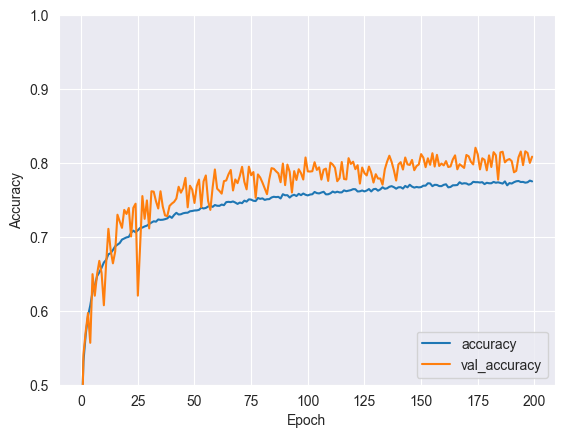

In [32]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose = 2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


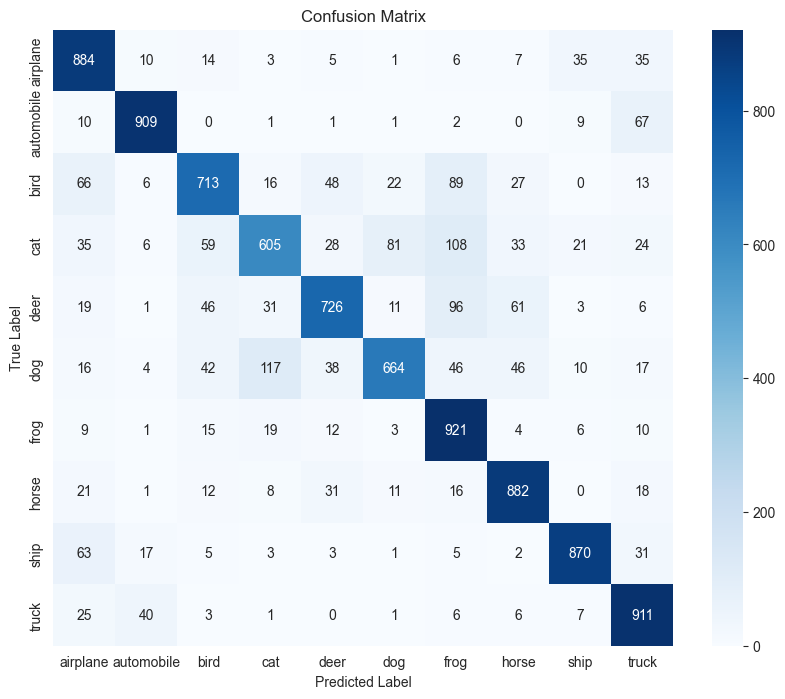

In [33]:
from sklearn.metrics import confusion_matrix

predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis = 1)

# CIFAR-10 labels are often 2D arrays
# We flatten them to 1D to match our predictions
true_classes = test_labels.flatten()

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a heatmap
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', 
            xticklabels = class_names, yticklabels = class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

We observe a clear improvement in stability so a combination of Droput and data augmentation yields in a notably stable learning curve that effectively suppresses overfitting. Despite the extended training, the model plateaus at approximately 80% accuracy, suggesting the architecture has reached its representational capacity and cannot extract deeper features from the data. 

It should be noted that no hyperparameter tuning has been applied, and adjusting the learning rate could yield incremental gains. To meaningfully push accuracy higher, the next logical step would be a more complex architecture or transfer learning with pre-trained ImageNet weights.

### References
* <a name="ref-santurkar"> </a>**Santurkar et al.(2018)**, "How does Batch Normalization Help Optimization?", Gradient Science, 2018. [Read Article](https://gradientscience.org/batchnorm/)

* <a name="ref-d2l"> </a> **Zhang, A., Lipton, Z. C., Li, M., & Smola, A. J. (2023)**, Dive into Deep Learning. Cambridge University Press. Available at: [https://d2l.ai](https://d2l.ai)

* <a name="ref-keras"></a> **Keras API documentation**, Available via: [keras.io](https://keras.io)

* <a name="ref-chollet"></a> **Chollet, F. (2025)**, Deep Learning with Python (3rd ed.). Manning Publications. Online-version available via: [deeplearningwithpython.io](https://deeplearningwithpython.io)

* <a name="ref-ibm"></a> **IBM Research (2023)**, What is data leakage in machine learning? IBM Think Topics. Available via: [ibm.com](https://www.ibm.com/think/topics/data-leakage-machine-learning)

### Acknowledgements
* **Foundational Coding:** The architectural design and implementation of the Keras model followed best practices and principles outlined in [Deep Learning with Python by François Chollet](https://deeplearningwithpython.io), ensuring a robust and standardized approach of deep learning.
* **Technical Implementation:** The logic for tensor dimensionality manipulation within the data augmentation loop was developed with the assistance of an AI tool. 

### Technical Remarks: 
The experimental results indicate a performance plateau at approximately 70% accuracy when utilizing the standard techniques outlined in the project scope (Augmentation and BN). However, by extending the architecture with Dropout and optimizing model capacity, we successfully elevated the accuracy to 80-81%. To surpass this threshold, future work would likely benefit from Transfer Learning to leverage robust feature maps learned from larger datasets. Additionally, a more exhaustive hyperparameter search could optimize the network. 